In [1]:
#%config InlineBackend.figure_formats=['svg']
from src.Utils import plot_traces, save_results, plot_poisson_confidence
from src.Dataset import dataset_TES
from src.ExistingAlgorithms import max_value, area, sklearn_available
from src.GaussianMixture import gaussian_mixture

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

import numpy as np
import matplotlib.pyplot as plt

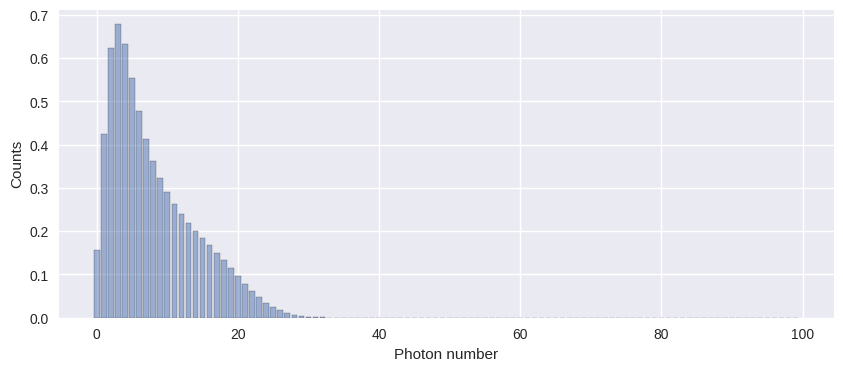

In [4]:
weights = [1]*7

Average = [1.80622346e+01, 1.27380046e+01, 9.02367143e+00, 6.40704597e+00, 
           4.54269070e+00, 3.20272751e+00, 2.26309906e+00]

n_cluster = [10, 10, 10, 10, 10, 10, 10]

path_save = 'src/Results/Low Dimension'

data_train, data_test = dataset_TES(weights = weights,
                                    signal_size = 8192,
                                    interval = [0,270],
                                    order_dB = True,
                                    plot_expected = True,
                                    plot_traces = False)
data_train_complete = np.concatenate(data_train)
data_test_complete = np.concatenate(data_test)

### PIKA

In [11]:
pk = PIKA(n_iter = 100, n_epoch = 10, N_mean = [2, 3])
pk.run_PIKA(X_test, plot=True)

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

ValueError: operands could not be broadcast together with shapes (2,) (10240,) 

### Max Value

In [5]:
X_l_MAX = max_value(data_test_complete, filter=True)

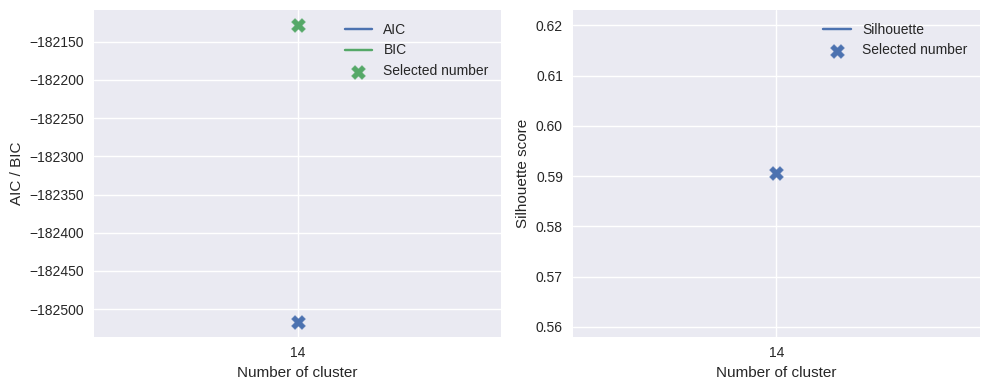

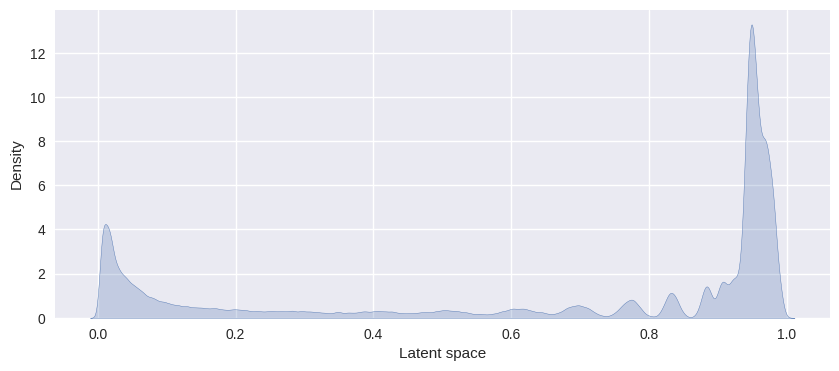

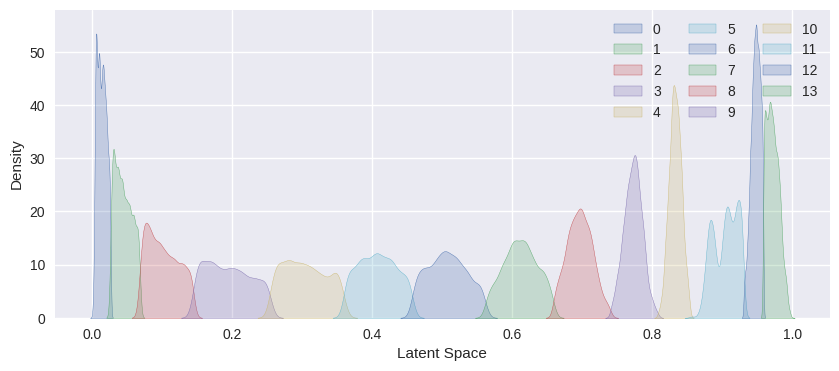

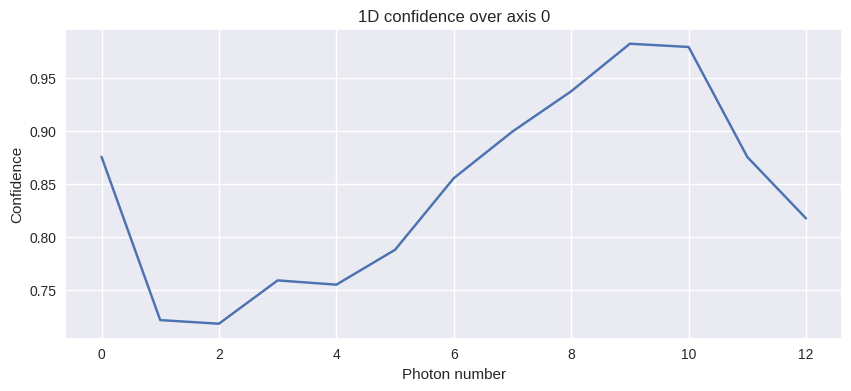

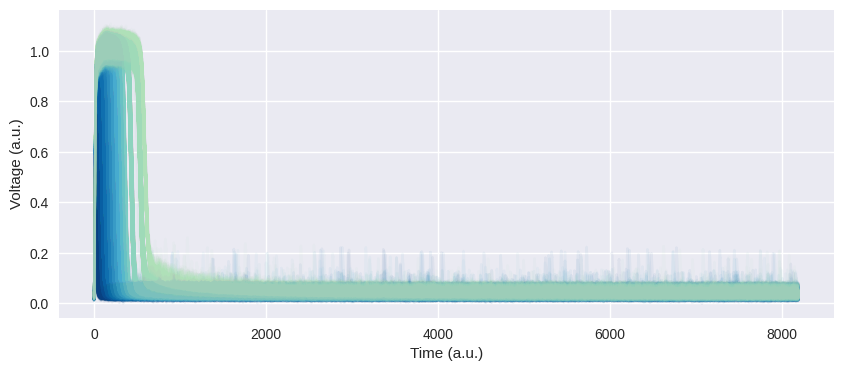

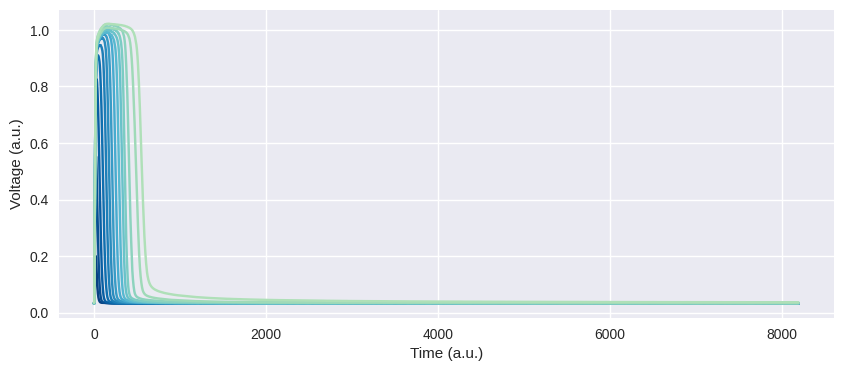

KeyboardInterrupt: 

In [7]:
condition = X_l_MAX[:,0] < 0.75
gm = gaussian_mixture(X_l_MAX, 
                    data_test_complete,
                    number_cluster = 14,
                    cluster_iter = 20,
                    info_sweep = 0,
                    plot_sweep = True,
                    dpi = 100)

gm.plot_density(bw_adjust = 0.1)
gm.plot_cluster(plot_kde = True)
gm.plot_confidence_1d(axis = 0) 
gm.plot_traces()
gm.plot_traces_average()
gm.plot_trustworthiness()

In [5]:
save_results(gm = gm, name_method = 'MAX')

### Area

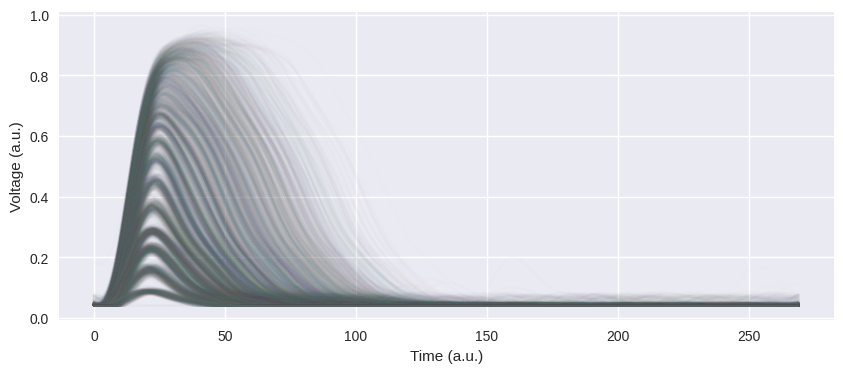

In [5]:
condition = np.max(data_test_complete,axis=1) > 0.08
X_l_AREA = []
for data in data_test_complete:
    X_l_AREA.append(area(data, filter = True, plot_filter = True, threshold = 0.04, cutoff = 0.05))

In [ ]:
conf = plot_poisson_confidence(average_list = Average,
                                n_cluster_list = n_cluster,
                                X_low = X_l_AREA,
                                X_high = data_test,
                                confidence_dimension = 1)

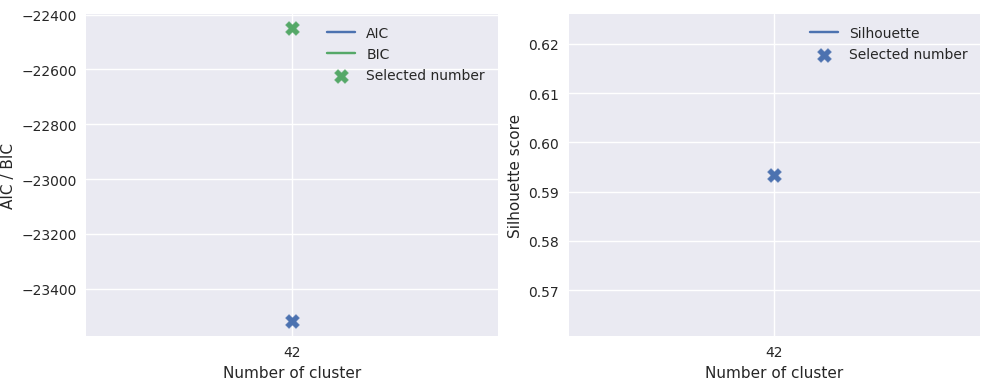

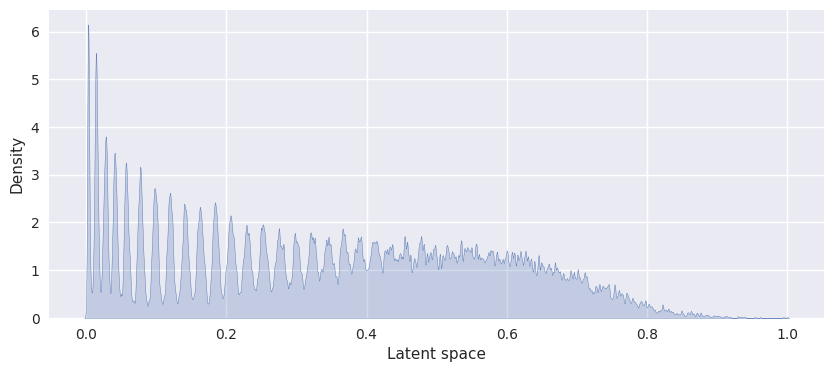

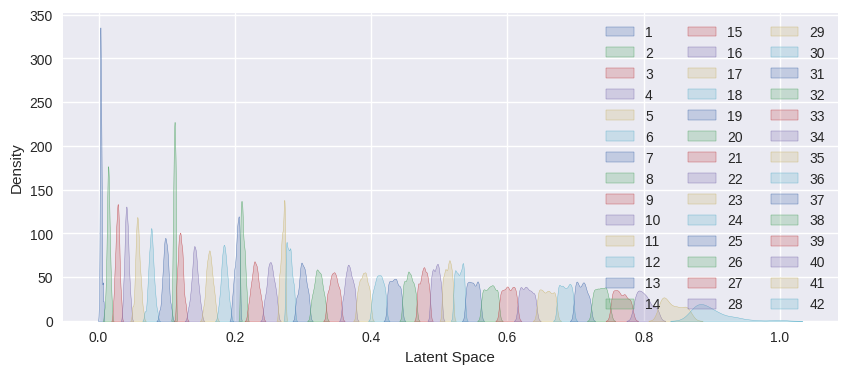

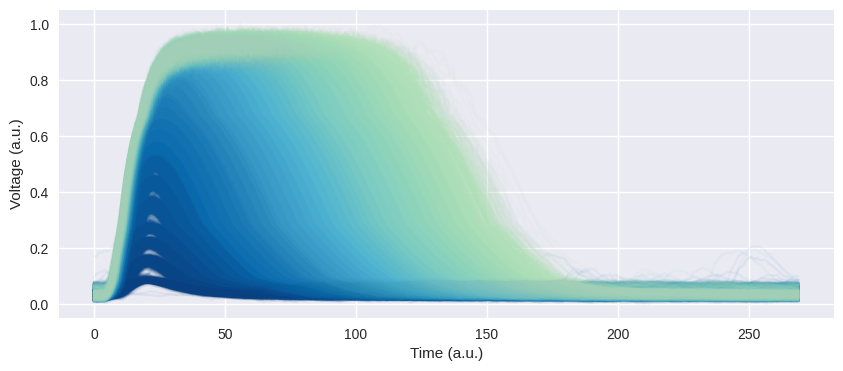

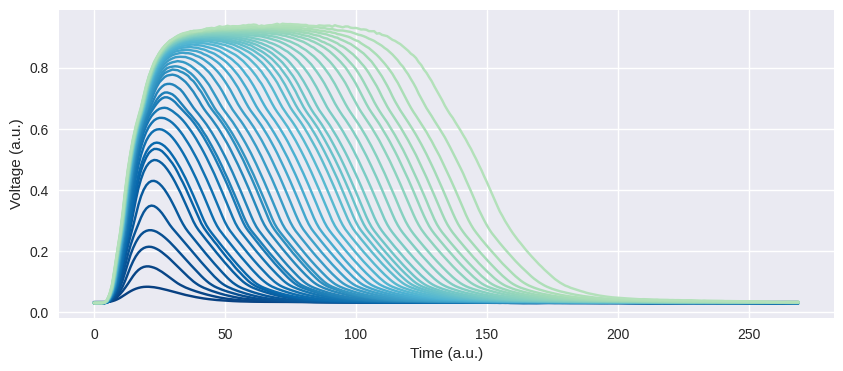

In [26]:
gm = gaussian_mixture(X_l_AREA,
                      data_test[condition],
                      number_cluster = 42,
                      cluster_iter = 20,
                      info_sweep = 0,
                      plot_sweep = True,
                      label_shift = 1)

gm.plot_density(bw_adjust = 0.03)
gm.plot_cluster(plot_kde = True, bw_adjust = 1)
gm.plot_traces()
gm.plot_traces_average()

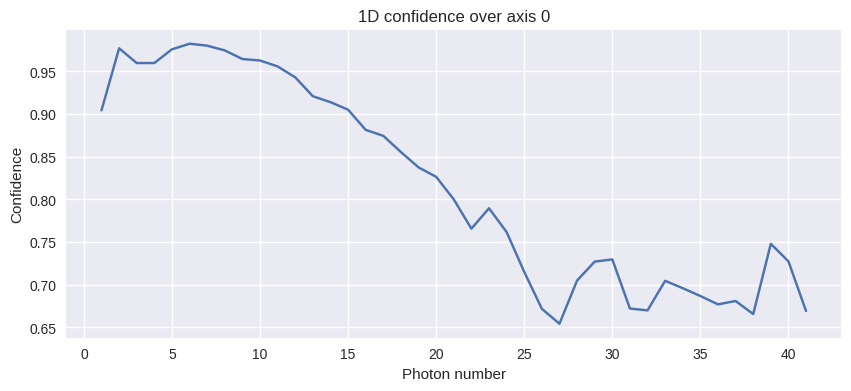

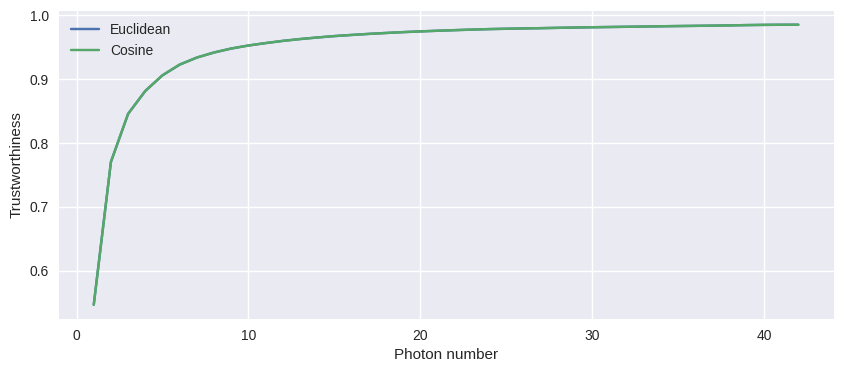

In [49]:
gm.plot_confidence_1d(axis = 0) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = 'AREA')

### Principal Component Analysis (PCA)

In [3]:
X_l_PCA = sklearn_available(data_train, data_test, path_save, PCA, n_components=2) 

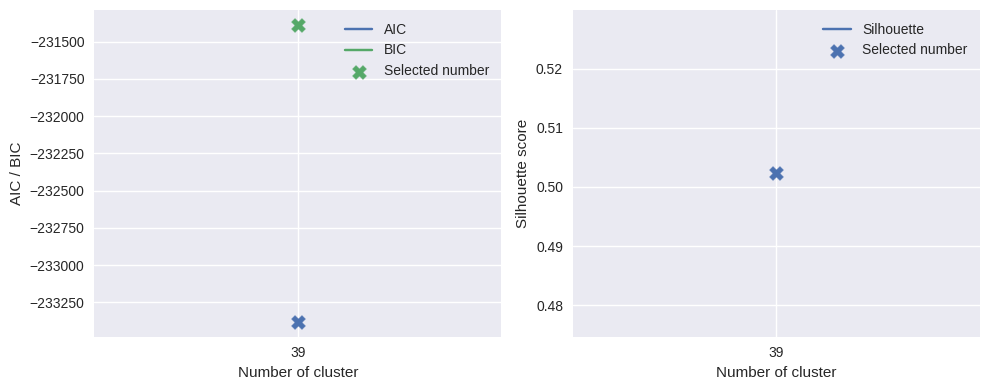

<Figure size 1000x400 with 0 Axes>

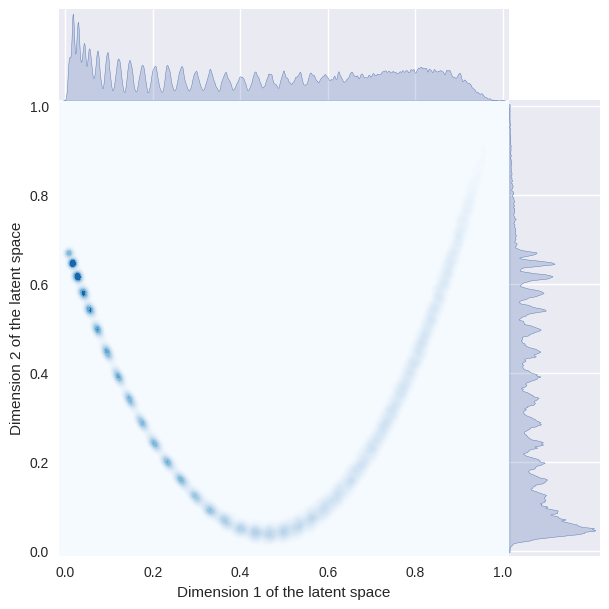

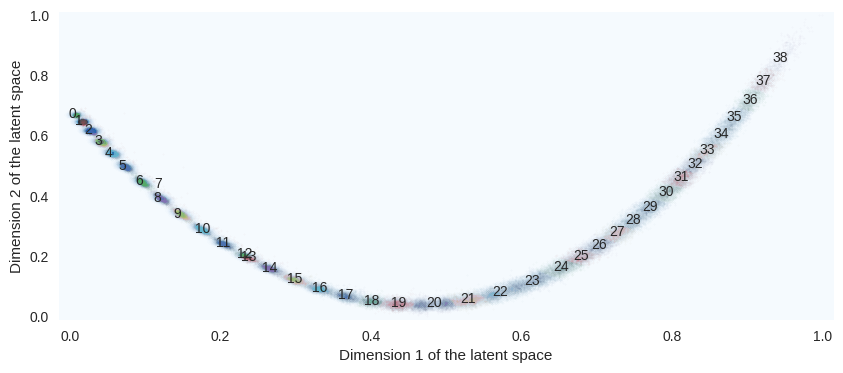

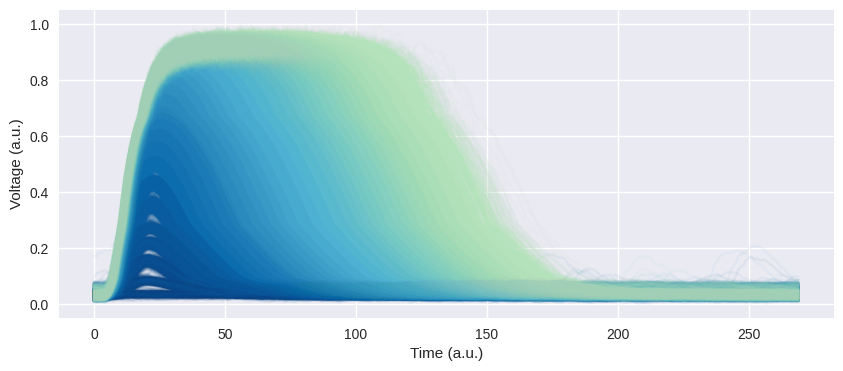

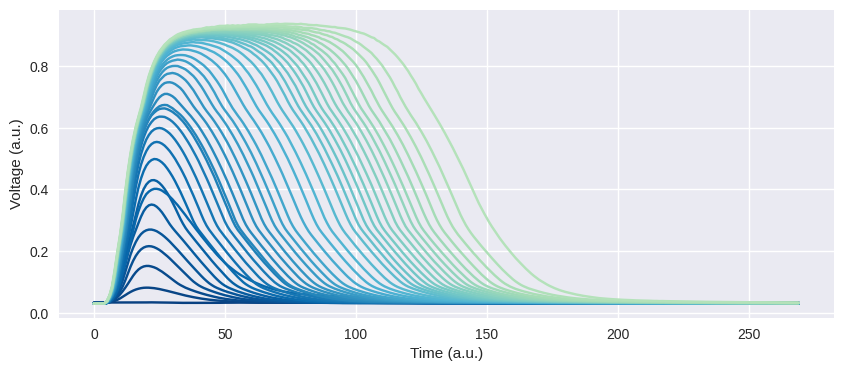

In [4]:
gm = gaussian_mixture(X_l_PCA,
                      data_test,
                      number_cluster = 39,
                      cluster_iter = 20,
                      tol = 1e-4,
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.1,
                bw_adjust_x = 0.05,
                bw_adjust_y = 0.05)
gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
gm.plot_traces()
gm.plot_traces_average()

In [ ]:
gm.plot_confidence_1d(axis = 0) 
gm.plot_confidence_2d()
gm.plot_trustworthiness()
save_results(gm = gm, name_method = 'PCA')

### Kernel PCA (Polynomial)

In [16]:
X_l_KPCA_P = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2, kernel="poly", gamma=0.1, fit_inverse_transform=True) 

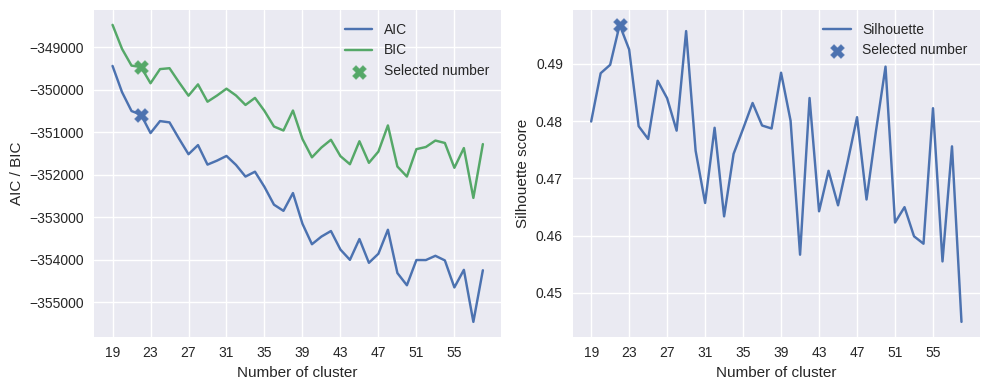

<Figure size 1000x400 with 0 Axes>

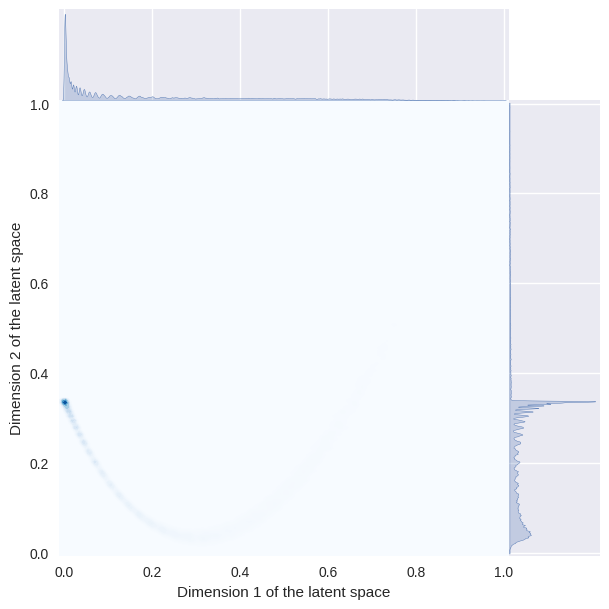

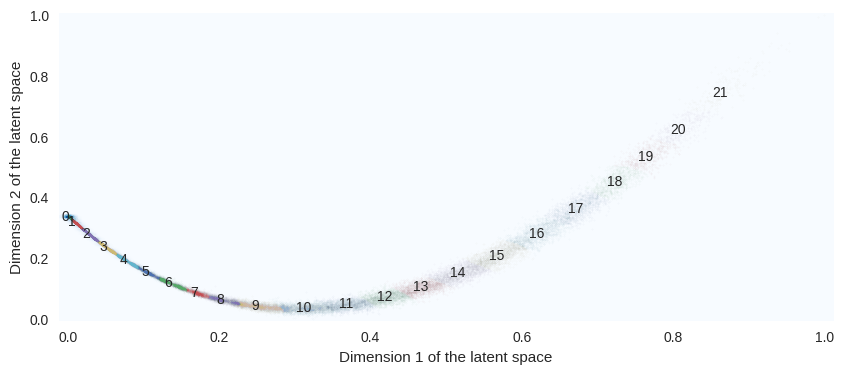

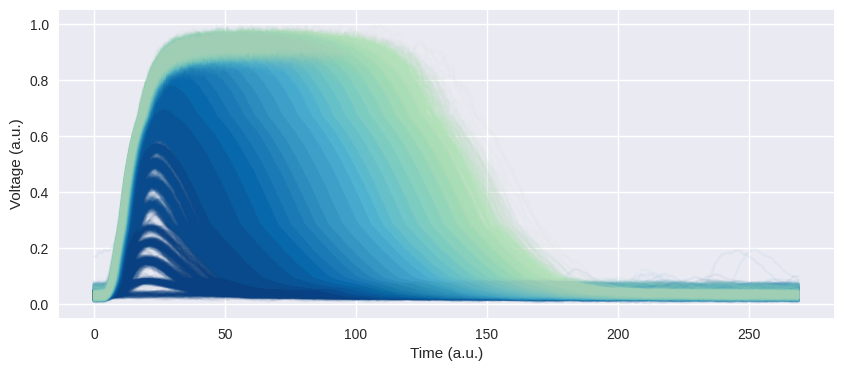

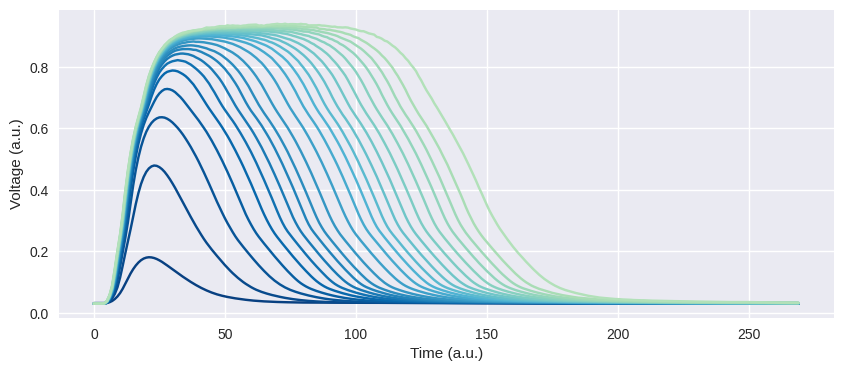

In [17]:
gm = gaussian_mixture(X_l_KPCA_P,
                      data_test,
                      number_cluster = 39,
                      cluster_iter = 30,
                      tol = 1e-3,
                      info_sweep = 20,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.1,
                bw_adjust_x = 0.05,
                bw_adjust_y = 0.05)
gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
gm.plot_traces()
gm.plot_traces_average()

In [ ]:
gm.plot_confidence_1d(axis = 0) 
gm.plot_confidence_2d()
gm.plot_trustworthiness()
save_results(gm = gm, name_method = 'KPCA_P')

### Kernel PCA (Radial basis function)

In [18]:
X_l_KPCA_RBF = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2,kernel="rbf",gamma=2, fit_inverse_transform=True) 

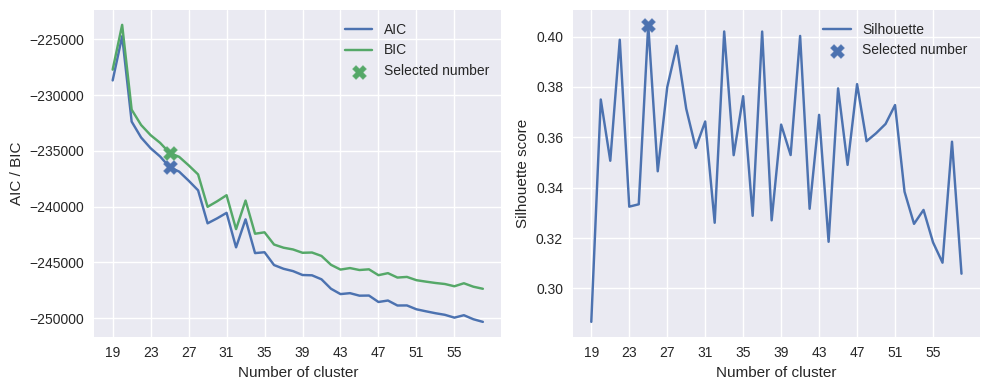

<Figure size 1000x400 with 0 Axes>

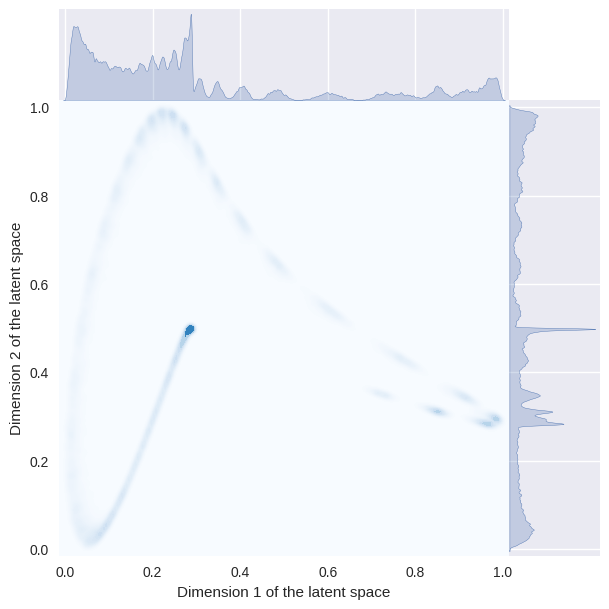

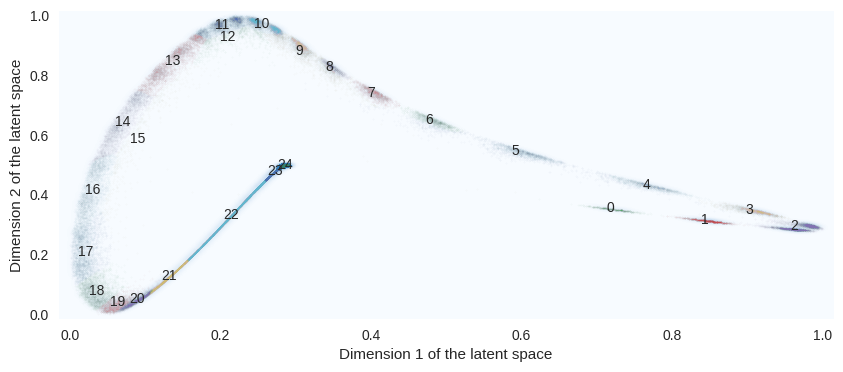

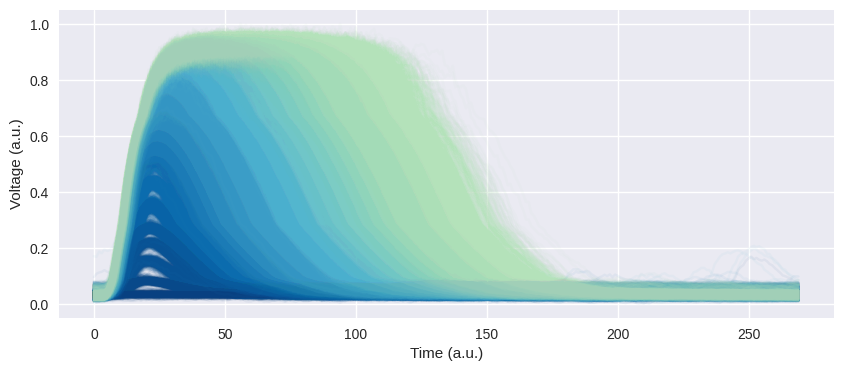

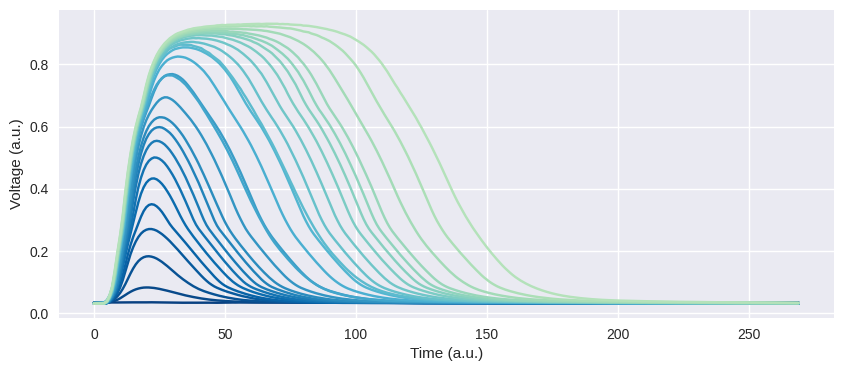

In [19]:
gm = gaussian_mixture(X_l_KPCA_RBF,
                      data_test,
                      number_cluster = 39,
                      cluster_iter = 30,
                      tol = 1e-4,
                      info_sweep = 20,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.1,
                bw_adjust_x = 0.05,
                bw_adjust_y = 0.05)
gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
gm.plot_traces()
gm.plot_traces_average()

In [ ]:
gm.plot_confidence_1d(axis = 0) 
gm.plot_confidence_2d()
gm.plot_trustworthiness()
save_results(gm = gm, name_method = 'KPCA_RBF')

### Kernel PCA (Sigmoid)

In [20]:
X_l_KPCA_S = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2,kernel="sigmoid",gamma=0.01, fit_inverse_transform=True) 

In [21]:
gm = gaussian_mixture(X_l_KPCA_S,
                      data_test,
                      number_cluster = 39,
                      cluster_iter = 30,
                      tol = 1e-4,
                      info_sweep = 20,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.1,
                bw_adjust_x = 0.05,
                bw_adjust_y = 0.05)
gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
gm.plot_traces()
gm.plot_traces_average()

KeyboardInterrupt: 

In [ ]:
gm.plot_confidence_1d(axis = 0) 
gm.plot_confidence_2d()
gm.plot_trustworthiness()
save_results(gm = gm, name_method = 'KPCA_S')

### Kernel PCA (Cosine)

In [9]:
X_l_KPCA_C = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2,kernel="cosine",gamma=2, fit_inverse_transform=True) 

In [ ]:
gm = gaussian_mixture(X_l_KPCA_C,
                      data_test,
                      number_cluster = 39,
                      cluster_iter = 30,
                      tol = 1e-5,
                      info_sweep = 20,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.1,
                bw_adjust_x = 0.05,
                bw_adjust_y = 0.05)
gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
gm.plot_traces()
gm.plot_traces_average()

In [ ]:
gm.plot_confidence_1d(axis = 0) 
gm.plot_confidence_2d()
gm.plot_trustworthiness()
save_results(gm = gm, name_method = 'KPCA_C')

### t-distributed Stochastic Neighbor Embedding (t-SNE)

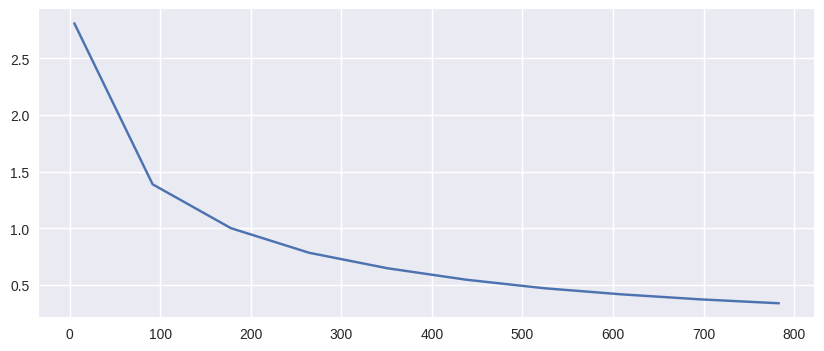

In [13]:
n_samples = data_test.shape[0]
perplexity = np.linspace(5, 4*np.sqrt(n_samples), 10)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i)
    reduced = model.fit_transform(data_test)
    divergence.append(model.kl_divergence_)

with plt.style.context("seaborn-v0_8"):
    plt.figure(figsize = (10,4))
    plt.plot(perplexity, divergence)
    plt.show()

In [26]:
X_l_tSNE = sklearn_available(data_train, data_test, path_save, TSNE,n_components=2, perplexity = 500) 

Method does not have a transform method


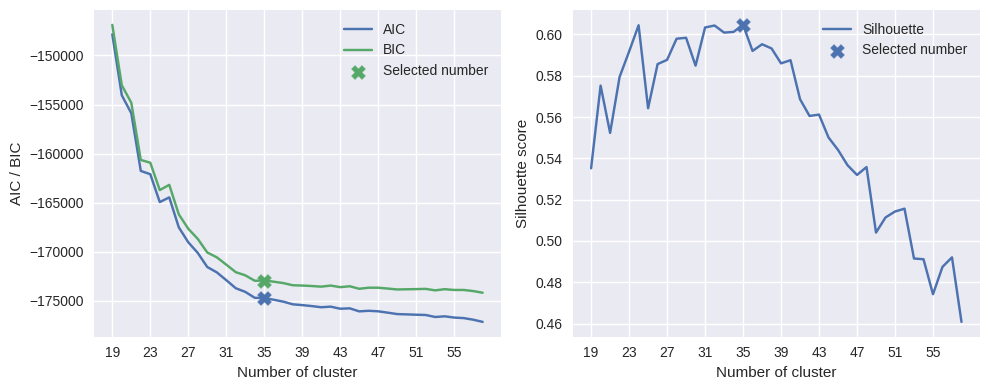

<Figure size 1000x400 with 0 Axes>

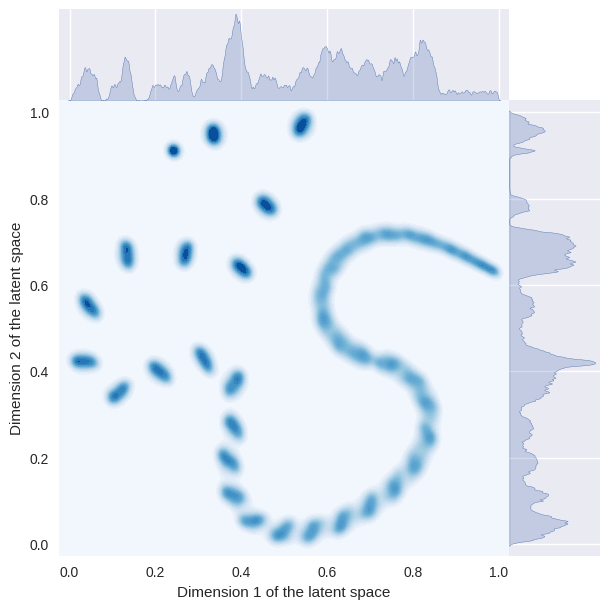

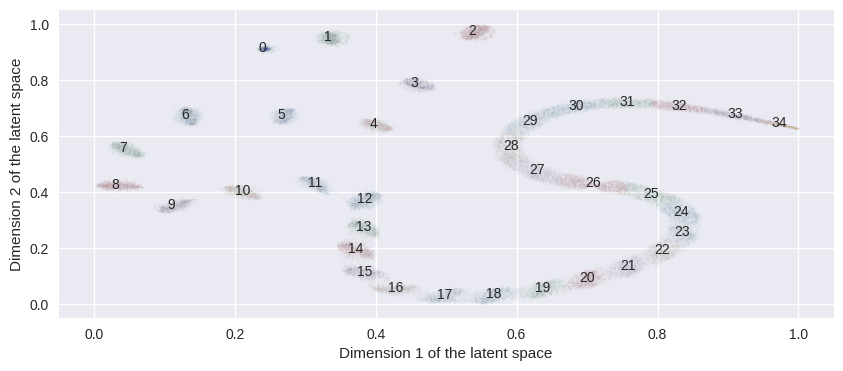

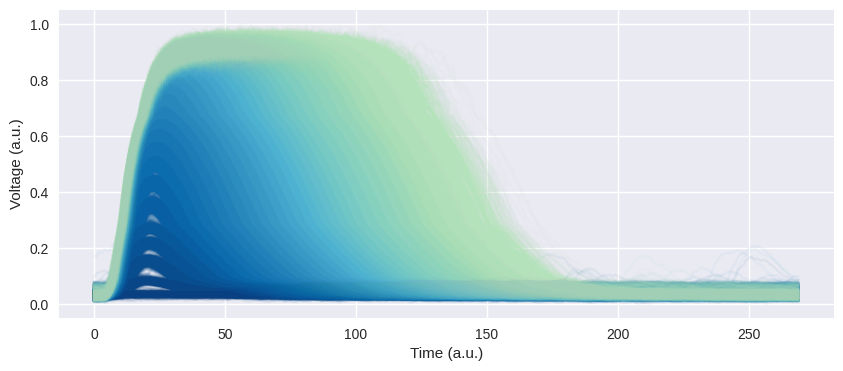

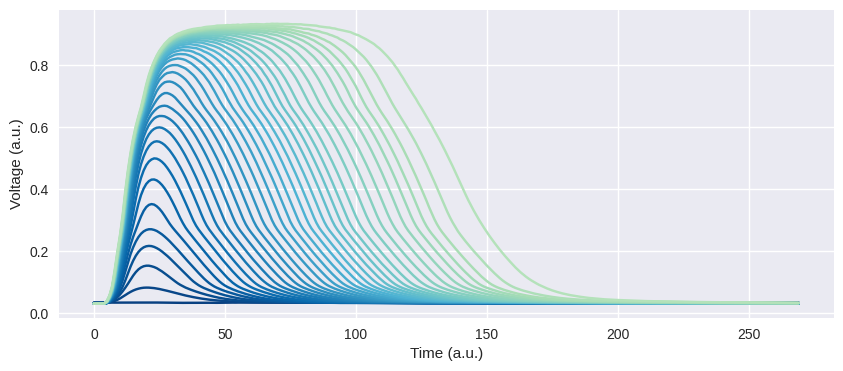

In [27]:
gm = gaussian_mixture(X_l_tSNE,
                      data_test,
                      number_cluster = 39,
                      cluster_iter = 20,
                      tol = 1e-3,
                      info_sweep = 20,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.2,
                bw_adjust_x = 0.05,
                bw_adjust_y = 0.05)
gm.plot_cluster(plot_kde = False, bw_adjust = 0.1)
gm.plot_traces()
gm.plot_traces_average()

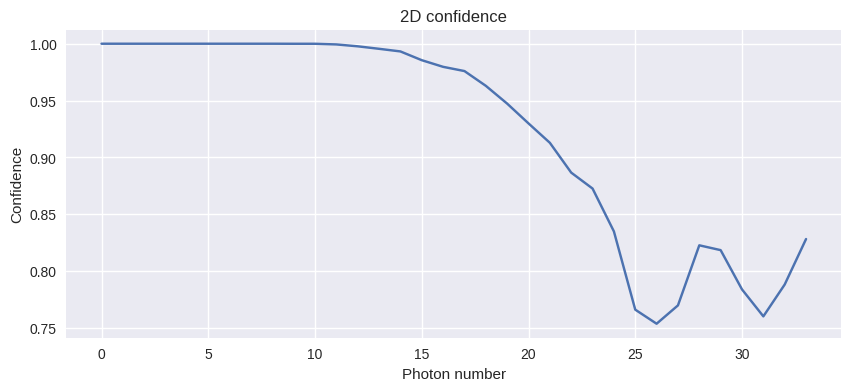

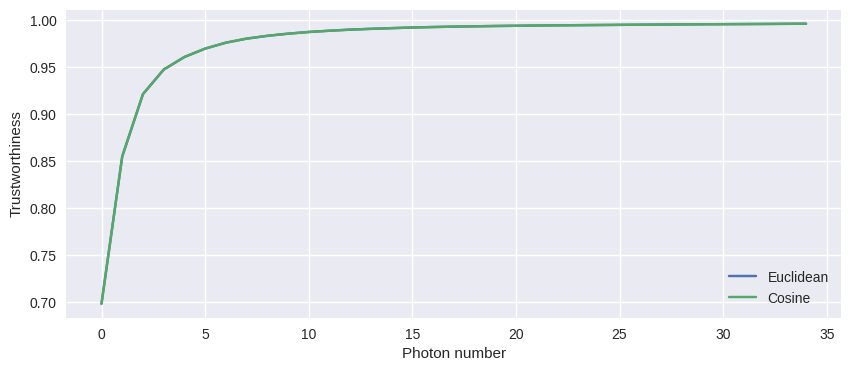

In [28]:
gm.plot_confidence_2d()
gm.plot_trustworthiness()
save_results(gm = gm, name_method = 'tSNE')

### Spectral Embedding 

In [ ]:
#X_i_SE, X_r_SE, X_l_SE = dimension_reduction(np.copy(X),SpectralEmbedding,n_components=1)
#plot_1D(X_l_SE)

### Non-Negative Matrix Factorization (NMF)

In [11]:
X_l_NMF = sklearn_available(data_train, data_test, path_save, NMF,n_components=2,alpha_W=1e-2,random_state=42) 

In [ ]:
kd = gaussian_mixture_2d(X_l_NMF, data_test,
                    number_cluster=37,#17,
                    cluster_iter = 10)    

kd.plot_density(bw_adjust=0.1)
kd.plot_cluster()
#kd.plot_psn()
#kd.plot_pns()
#kd.plot_confidence()

### Isomap

In [12]:
X_i_ISO, X_l_ISO = dimension_reduction(data_train,data_test, path_save, Isomap, n_neighbors=100, n_components=2, eigen_solver="arpack")
trust_ISO_eucl = trustworthiness(data_test, X_l_ISO, metric="euclidean")
trust_ISO_cos = trustworthiness(data_test, X_l_ISO, metric="cosine")

In [ ]:
kd = gaussian_mixture_2d(X_l_ISO, data_test,
                    number_cluster=29,#17,
                    cluster_iter = 10)    

kd.plot_density(bw_adjust=0.25)
kd.plot_cluster()
#kd.plot_psn()
#kd.plot_pns()
#kd.plot_confidence()
#kd.plot_traces(data_test)
#kd.plot_traces_average(data_test)

In [ ]:
kd = gaussian_mixture(X_l_ISO, 
                    number_cluster=24,
                    flip = False)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

### Autoencoder



In [15]:
path_model = 'grid-search-TES 2D 4/run 17/fold 0'
X_i_AUTO, X_r_AUTO, X_l_AUTO = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', filter=False, flip=True)

In [ ]:
plot_traces(X_r_AUTO)

In [ ]:
from scipy.signal import peak_widths

width =[]
for index, trace in enumerate(X_r_AUTO):
    half = peak_widths((trace-np.max(trace)/2).flatten(), peaks=[np.argmax(trace)], rel_height=0.5)
    width.append(half[0])

width = np.array(width)

In [ ]:
plt.figure()
plt.hist(width.flatten(), bins=5000)
plt.show()

In [ ]:
kd = gaussian_mixture_2d(X_l_AUTO, data_test,
                    number_cluster=29)    

kd.plot_density(bw_adjust=0.15)
kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()
kd.plot_traces(data_test)
kd.plot_traces_average(data_test)

In [ ]:
import matplotlib.pyplot as plt

plt.plot(kd.cluster_means[:15])
plt.show()

In [ ]:
X_i_AUTOF, X_r_AUTOF, X_l_AUTOF = loadAutoencoder(np.copy(X_test), f'AutoencoderLog/{path_model}', 
                                                  filter=True, 
                                                  threshold=0.003)

In [ ]:
import matplotlib.pyplot as plt


plt.figure()
plt.scatter(X_l_AUTOF[:,0],X_l_AUTOF[:,1], s=1, alpha=0.01)#, c=X_l_AREA)
plt.show()

In [ ]:
kd = gaussian_mixture(X_l_AUTO, 
                    number_cluster=18,
                    flip = True)

kd.plot_cluster()
kd.plot_psn()
kd.plot_pns()
kd.plot_confidence()

In [ ]:
plt.plot(kd.cluster_means[:14])
plt.show()

# Compare

In [ ]:
i = [X_i_MAX, X_i_AREA, X_i_PCA, #X_i_KPCA_P, 
     X_i_KPCA_RBF, X_i_KPCA_S, 
     X_i_KPCA_C, X_i_NMF, 
     X_i_TSNE, X_i_ISO, 
      X_i_AUTO, X_i_AUTOF]
l = [X_l_MAX, X_l_AREA, X_l_PCA, #X_l_KPCA_P, 
     X_l_KPCA_RBF, X_l_KPCA_S, 
     X_l_KPCA_C, X_l_NMF,
     X_l_TSNE, X_l_ISO,
      X_l_AUTO, X_l_AUTOF]
#r = [X_r_MAX, X_r_AREA, X_r_PCA, #X_r_KPCA_P, 
#     #X_r_KPCA_RBF, X_r_KPCA_S, 
#     X_r_KPCA_C, X_r_NMF,
#     X_r_TSNE, X_r_ISO, 
#      X_r_AUTO, X_r_AUTOF]
methods = ['Max', 'Area', 'PCA', #'K-PCA (Polynomial)', 
           'K-PCA (RBF)', 'K-PCA (Sigmoid)', 
           'K-PCA (Cosine)', 'NMF', 
           't-SNE', 'Isomap',
           'Autoencoder', 'Autoencoder\nFiltered']
flip = [False, False,False,#False,False,False,
        False,False,False,False, True, False]
density_kernel = ['gaussian', 'gaussian', #'gaussian', #'gaussian', #'gaussian',
                  'gaussian', 'gaussian', 'gaussian', 'exponential', 'gaussian',
                  'gaussian', 'gaussian']
bw = [0.0032, 0.003, 0.0025, 0.0035,
      #0.005, 0.008, 0.0045, 
      0.0035, 0.015, 0.0045,
      0.003, 0.003]

#comp = compare(flip, density_kernel, bw)
#scores = comp.quality_metric_plot(i,l,methods, 23)

In [ ]:
#import numpy as np

#np.save("MetricLog/Metric_TES_25.5dB/MetricTES_23photons", scores)

In [14]:
trust_eucl = [trust_MAX_eucl, trust_AREA_eucl, trust_PCA_eucl, trust_KPCA_RBF_eucl, trust_KPCA_S_eucl, trust_KPCA_C_eucl, trust_tsne_eucl, trust_NMF_eucl, trust_ISO_eucl]
trust_cos = [trust_MAX_cos, trust_AREA_cos, trust_PCA_cos, trust_KPCA_RBF_cos, trust_KPCA_S_cos, trust_KPCA_C_cos, trust_tsne_cos, trust_NMF_cos, trust_ISO_cos]

In [17]:
Title = ['Max', 'Area', 'PCA', #'K-PCA (Polynomial)',
           'K-PCA (RBF)', 'K-PCA (Sigmoid)',
           'K-PCA (Cosine)', 'NMF', 't-SNE', 'Isomap',
           'Autoencoder']
metric_list = ['Silhouette','Calinski Harabasz','Davies Bouldin','trustworthiness Euclidian','trustworthiness Cosine']

#colors = get_color_gradient(r"#19889B", r"#F9F871", 10)
GREY98 = "#fafafa"
colors = ["#81C14B", "#81C14B", "#6D7680", "#6D7680", #"#6D7680", "#6D7680" , 
          "#6D7680", "#6D7680", "#E0607E", "#E0607E", "#79AEA3", "#79AEA3"]
ylim = [None, None, None, (0.9,1), (0.9,1)]

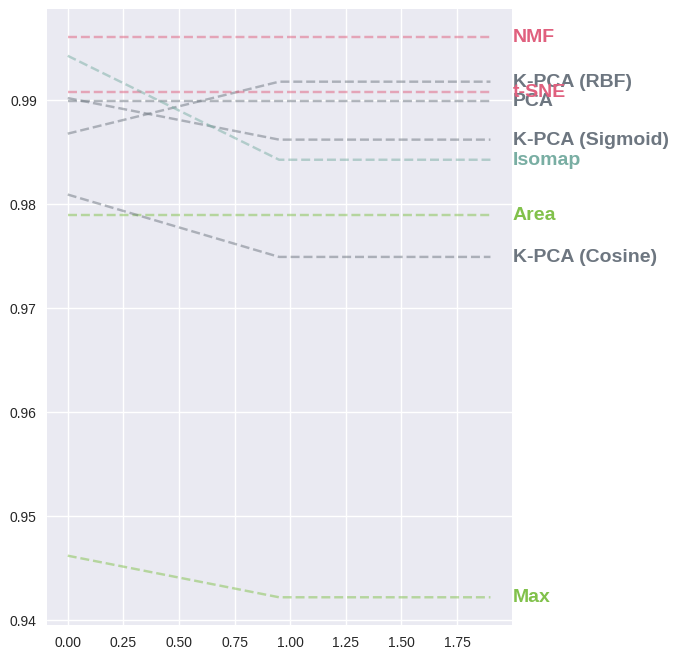

In [27]:
LABEL_Y = [# Positions Silhouette
    -0.004,  # Max
    0,  # Area
    -0.00,    # PCA
    #-0.013,   # K-PCA (Polynomial)
    0.005,  # K-PCA (RBF)
    -0.004,   # K-PCA (Sigmoid)
    -0.006,  # K-PCA (Cosine)
    0.0,    # NMF
    -0.00,  # t-SNE
    -0.01,  # Isomap
    0,  # Autoencoder
]

PAD = 0.1

with plt.style.context("seaborn-v0_8"):
    fig, axis = plt.subplots(figsize=(6,8))

    for index_method, score in enumerate(trust_eucl):

        sc = score
        sc = sc[sc != 0]
        color = colors[index_method]
        y_start = sc[-1]
        y_end = sc[-1] +LABEL_Y[index_method]
        x_start = len(sc)-1
        x_end = len(sc)+1

        axis.plot(score, c=color)
        axis.plot([x_start, (x_start + x_end - PAD) / 2 , x_end - PAD], 
                    [y_start, y_end, y_end], 
                    color=color, 
                    alpha=0.5, 
                    ls="dashed")
        axis.text(x_end, 
                y_end, 
                Title[index_method], 
                color=color, 
                fontsize=14, 
                weight="bold", 
                va="center")

    plt.show()

In [ ]:
for index_metric, metric_score in enumerate(scores):

    fig, axis = plt.subplots(figsize=(6,8))
    #fig.patch.set_facecolor(GREY98)
    #axis.set_facecolor(GREY98)

    for index_method, method in enumerate(Title):

        try:
            sc = scores[index_metric][index_method]
            sc = sc[sc != 0]
            color = colors[index_method]
            y_start = sc[-1]
            y_end = sc[-1] +LABEL_Y[index_metric][index_method]
            x_start = len(sc)-1
            x_end = len(sc)+1

            axis.plot(sc, label=f"{Title[index_method]}", c=color)
            axis.plot([x_start, (x_start + x_end - PAD) / 2 , x_end - PAD], 
                    [y_start, y_end, y_end], 
                    color=color, 
                    alpha=0.5, 
                    ls="dashed")
            axis.text(x_end, 
                    y_end, 
                    Title[index_method], 
                    color=color, 
                    fontsize=14, 
                    weight="bold", 
                    va="center")
        except:
            pass

    axis.set_xlim(0,31)
    axis.set_ylabel(f"{metric_list[index_metric]}")
    axis.set_xlabel('Photon number')
    if ylim[index_metric] != None:
        axis.set_ylim(ylim[index_metric][0],ylim[index_metric][1])
    #axis.set_yscale('log')
    plt.tight_layout()
    plt.show()